In [13]:
import re
from typing import List, TypedDict
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from pydantic.v1 import BaseModel

load_dotenv()

True

In [2]:
docs=(
    PyPDFLoader("./documents/book1.pdf").load()+
    PyPDFLoader("./documents/book2.pdf").load()+
    PyPDFLoader("./documents/book3.pdf").load()
)

In [3]:
len(docs)

2123

In [4]:
chunks=RecursiveCharacterTextSplitter(chunk_size=900,chunk_overlap=150).split_documents(docs)

for d in chunks:
    d.page_content = d.page_content.encode("utf-8","ignore").decode("utf-8","ignore")

In [5]:
len(chunks)

6685

In [6]:
embeddings=OpenAIEmbeddings(model="text-embedding-3-large")
vector_store=FAISS.from_documents(chunks,embeddings)

In [7]:
retriever=vector_store.as_retriever(search_type='similarity',seach_kwargs={"k":4})

In [8]:
llm=ChatOpenAI(model="gpt-4o-mini",temperature=0)

In [9]:
class State(TypedDict):
    question:str
    docs:List[Document]
    answer:str

    strips:List[str]
    kept_strips:List[str]
    refined_context:str

In [10]:
def retrieve(state):
    q=state['question']

    return {"docs":retriever.invoke(q)}

In [15]:
def decompose_to_sentence(text:str)->List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)

    return [s.strip() for s in sentences if len(s.strip())> 20]

class KeepOrDrop(BaseModel):
    keep:bool

filter_prompt=ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain= filter_prompt | llm.with_structured_output(KeepOrDrop)

def refine(state:State) -> State:
    q=state["question"]

    context="\n\n".join(d.page_content for d in state['docs']).strip()

    strips=decompose_to_sentence(context)

    kept:List[str]=[]

    for s in strips:
        if filter_chain.invoke({"question":q,"sentence":s}).keep:
            kept.append(s)

    refined_context="\n".join(kept).strip()

    return {
        "strips":strips,
        "kept_strips":kept,
        "refined_context":refined_context,
    }

In [16]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "refined_context": state['refined_context']})
    return {"answer": out.content}

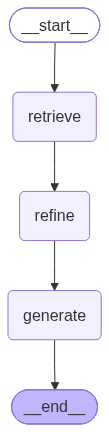

In [17]:
g=StateGraph(State)
g.add_node("retrieve",retrieve)
g.add_node("refine",refine)
g.add_node("generate",generate)

g.add_edge(START,"retrieve")
g.add_edge("retrieve","refine")
g.add_edge("refine","generate")
g.add_edge("generate",END)

app=g.compile()

app

In [21]:
res = app.invoke({
    "question": "Explain the bias–variance tradeoff",
    "docs": [],
    "strips": [],
    "kept_strips": [],
    "refined_context": "",
    "answer": ""
})
print(res["answer"])

The bias–variance tradeoff is a fundamental concept in statistics and machine learning that describes the relationship between two sources of error in an estimator: bias and variance. 

- **Bias** measures the expected deviation from the true value of the function or parameter. A high-bias model is likely to underfit the training data, often due to incorrect assumptions about the data (e.g., assuming linearity when the relationship is quadratic).
  
- **Variance** measures the model's sensitivity to small variations in the training data. A model with high variance may fit the training data very well but perform poorly on unseen data due to overfitting.

The generalization error of a model can be expressed as the sum of bias, variance, and a constant noise term. 

- There is a trade-off between bias and variance: flexible models tend to have low bias and high variance, while rigid models have high bias and low variance. 

- The goal is to minimize expected loss by finding the optimal ba

In [22]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

5.4.4 TradingoﬀBiasandVariancetoMinimize MeanSquared
Error
Bias and variance measure two diﬀerent sources of error in an estimator. Bias
measures the expected deviation from the true value of the function or parameter.
Variance on the other hand, provides a measure of the deviation from the expected
estimator value that any particular sampling of the data is likely to cause.
What happens when we are given a choice between two estimators, one with
more bias and one with more variance? How do we choose between them? For
example, imagine that we are interested in approximating the function shown in
ﬁgure and we are only oﬀered the choice between a model with large bias and5.2
one that suﬀers from large variance. How do we choose between them?
The most common way to negotiate this trade-oﬀ is to use cross-validation.
****************************************************************************************************
10 This notion of bias is not to be confused with the bias term of linear 

In [23]:
print(res['refined_context'])

5.4.4 TradingoﬀBiasandVariancetoMinimize MeanSquared Error Bias and variance measure two diﬀerent sources of error in an estimator.
Bias measures the expected deviation from the true value of the function or parameter.
What happens when we are given a choice between two estimators, one with more bias and one with more variance?
For example, imagine that we are interested in approximating the function shown in ﬁgure and we are only oﬀered the choice between a model with large bias and5.2 one that suﬀers from large variance.
The Bias/Variance Tradeoff An importan t theoretical result of statistics and Machine Learning is the fact that a model’s generaliza tion error can be expressed as the sum of three very different errors: Bias This part of the generalization error is due to wrong assumptions, such as assum‐ ing that the data is linear when it is actually quadratic.
A high-bias model is most likely to underfit the training data.10 Variance This part is due to the model’s excessive sens

In [24]:
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

In [25]:
decompose_to_sentences("""A transformer in deep learning is a type of model architecture that is particularly effective for processing sequential data, such as text. It utilizes mechanisms called self-attention and feedforward neural networks to weigh the importance of different parts of the input data, allowing it to capture long-range dependencies and relationships within the data. Unlike traditional recurrent neural networks (RNNs), transformers do not process data sequentially, which enables them to be more parallelizable and efficient in training. This architecture has become foundational in natural language processing tasks and has led to significant advancements in the field.""")

['A transformer in deep learning is a type of model architecture that is particularly effective for processing sequential data, such as text.',
 'It utilizes mechanisms called self-attention and feedforward neural networks to weigh the importance of different parts of the input data, allowing it to capture long-range dependencies and relationships within the data.',
 'Unlike traditional recurrent neural networks (RNNs), transformers do not process data sequentially, which enables them to be more parallelizable and efficient in training.',
 'This architecture has become foundational in natural language processing tasks and has led to significant advancements in the field.']